 # Macro-Driven Credit Stress Testing | Vasicek Single-Factor Model, CCAR-Style Scenarios & Basel IRB Framework
 
## Introduction

### This project extends the **Credit Probability of Default (PD) Model** (see companion repo: `credit-pd-model`) by simulating how portfolio credit risk behaves under macroeconomic stress. Where the PD model estimates each borrower's default probability under *current* conditions, this project asks: **what happens to those default probabilities — and the bank's expected losses — during a recession?**

### This mirrors the workflow used by credit risk and model risk teams for regulatory stress testing programs such as the Federal Reserve's **CCAR/DFAST** and **IFRS 9** forward-looking expected credit loss requirements.
# ---
## Why Vasicek, not a direct macro regression?

### The source dataset (`credit_risk_csv.csv`) is **cross-sectional** — a single snapshot of borrowers with no origination date or time series of quarterly default rates. This means a direct regression of `default_rate ~ macro_variables` over time is not possible with this data (you'd need years of quarterly vintage-level default data for that, which is the approach used in Project extension #2 if such data becomes available).
 
### Instead, this project uses the **Vasicek single-factor asset value model** — the same model underlying the **Basel II/III Internal Ratings-Based (IRB) capital formula**. It works directly on cross-sectional PDs by conditioning them on a systematic macroeconomic factor `Z`:
 
### $$PD_{stressed} = \\Phi\\left(\\frac{\\Phi^{-1}(PD_{baseline}) - \\sqrt{\\rho}\\cdot Z}{\\sqrt{1-\\rho}}\\right)$$
 
## Where:
### - `PD_baseline` — each borrower's PD from the trained XGBoost model
### - `ρ (rho)` — asset correlation (Basel retail formula, PD-dependent)
### - `Z` — systematic macroeconomic factor (Z < 0 = adverse economic state, calibrated from CCAR-style scenario shocks)
### - `Φ` — standard normal CDF, `Φ⁻¹` — its inverse (probit)
 
### This is the exact mechanism regulators use to translate macro scenarios into stressed capital requirements, so it's a legitimate and defensible way to stress-test a cross-sectional retail credit portfolio.
 
# ---
 
## Objectives
 
### * Reuse the trained XGBoost PD model to generate baseline borrower-level PDs
### * Design three macroeconomic scenarios (Baseline / Adverse / Severely Adverse), calibrated in the style of Federal Reserve CCAR scenarios
### * Translate each scenario into a systematic factor `Z` using standardized macro shocks
### * Apply the Vasicek transformation to obtain stressed PDs for every borrower under every scenario
### * Compute stressed **Expected Loss (EL = PD × LGD × EAD)** at the portfolio level
### * Analyze risk-band migration — how many borrowers move into higher-risk bands under stress
### * Estimate the directional capital impact using the Basel IRB risk-weight formula
 
# ---
 
## Assumptions (stated explicitly, as any model risk validator would require)
 
### | Assumption | Value | Rationale |

### | Loss Given Default (LGD) | 45% | Basel Foundation-IRB benchmark for senior unsecured exposures |
### | Exposure at Default (EAD) | `loan_amnt` | Term loans, fully drawn, no revolving CCF adjustment needed |
### | Asset correlation (ρ) | Basel "other retail" formula, PD-dependent (0.03–0.16) | Standard regulatory formula for retail/consumer credit |
### | Macro shock standard deviations | ΔUnemployment σ ≈ 1.0pp/qtr, ΔGDP growth σ ≈ 2.0%/qtr | Approximate historical quarterly volatility of US macro series |
### | Scenario severity | Loosely calibrated to Fed CCAR Adverse / Severely Adverse scenario magnitudes | For illustrative, methodologically-sound stress testing — not an official regulatory submission |

### 1. Required Libraries : 

In [24]:
import numpy as np
import pandas as pd
 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
 
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score
 
from xgboost import XGBClassifier
 
import warnings
warnings.filterwarnings("ignore")
 
sns.set_theme(style="whitegrid", palette="muted") 

## 2. Load Data & Rebuild Features : 

In [26]:
''' This section reuses the exact feature engineering from the PD model project,
so the stressed portfolio is built on the same feature set the model was trained on.'''
 
df = pd.read_csv("credit_risk_csv.csv")
 
print("Shape:", df.shape)
df.head() 

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0000,PERSONAL,D,35000,16.0200,1,0.5900,Y,3
1,21,9600,OWN,5.0000,EDUCATION,B,1000,11.1400,0,0.1000,N,2
2,25,9600,MORTGAGE,1.0000,MEDICAL,C,5500,12.8700,1,0.5700,N,3
3,23,65500,RENT,4.0000,MEDICAL,C,35000,15.2300,1,0.5300,N,2
4,24,54400,RENT,8.0000,MEDICAL,C,35000,14.2700,1,0.5500,Y,4


In [33]:
# LOAN-TO-INCOME RATIO (LTI)
df["loan_to_income_ratio"] = (
    df["loan_amnt"] / df["person_income"]
).round(4) 
print(df['loan_to_income_ratio']) 

0       0.5932
1       0.1042
2       0.5729
3       0.5344
4       0.6434
         ...  
32576   0.1094
32577   0.1469
32578   0.4605
32579   0.1000
32580   0.1542
Name: loan_to_income_ratio, Length: 32581, dtype: float64


In [34]:
# INCOME PER YEAR EMPLOYED
df["income_per_year_employed"] = (
    df["person_income"] / (df["person_emp_length"] + 1)
).round(4)
print(df["income_per_year_employed"]) 

0         475.8065
1        1600.0000
2        4800.0000
3       13100.0000
4        6044.4444
           ...    
32576   26500.0000
32577   24000.0000
32578   19000.0000
32579   25000.0000
32580   14000.0000
Name: income_per_year_employed, Length: 32581, dtype: float64


In [35]:
# CREDIT HISTORY AGE RATIO
df["credit_history_age_ratio"] = (
    df["cb_person_cred_hist_length"] / (df["person_age"] + 1)
).round(4) 
print(df["credit_history_age_ratio"]) 

0       0.1304
1       0.0909
2       0.1154
3       0.0833
4       0.1600
         ...  
32576   0.5172
32577   0.3455
32578   0.4242
32579   0.4561
32580   0.4478
Name: credit_history_age_ratio, Length: 32581, dtype: float64


In [36]:
# HIGH-RISK LOAN GRADE FLAG
df["high_risk_grade"] = np.where(
    df["loan_grade"].isin(["D", "E", "F", "G"]), 1, 0
) 
print(df["high_risk_grade"]) 

0        1
1        0
2        0
3        0
4        0
        ..
32576    0
32577    0
32578    0
32579    0
32580    0
Name: high_risk_grade, Length: 32581, dtype: int64


In [37]:
print("Feature engineering complete — shape:", df.shape)

Feature engineering complete — shape: (32581, 16)


## 3. Train the PD Model (XGBoost) 
### Same configuration as the base PD project — this becomes the baseline PD generator for the stress framework.

In [46]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) 

In [40]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include="object").columns 

In [41]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])  

In [42]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
]) 

In [43]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
]) 

In [44]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
]) 

In [45]:
xgb_pipeline.fit(X_train, y_train)
 
test_auc = roc_auc_score(y_test, xgb_pipeline.predict_proba(X_test)[:, 1])
print(f"Test ROC-AUC: {test_auc:.4f}") 

Test ROC-AUC: 0.9501


## 4. Baseline Portfolio PD

### Score the **full portfolio** (not just the test set) to get each borrower's baseline PD — this is the starting point that gets stressed under each macro scenario.

In [47]:
portfolio = df.copy()
portfolio["PD_baseline"] = xgb_pipeline.predict_proba(X)[:, 1] 

In [48]:
LGD = 0.45
portfolio["EAD"] = portfolio["loan_amnt"]
portfolio["EL_baseline"] = portfolio["PD_baseline"] * LGD * portfolio["EAD"] 

In [49]:
print("Portfolio-level baseline metrics")
print("-" * 45)
print(f"Number of borrowers        : {len(portfolio):,}")
print(f"Average baseline PD        : {portfolio['PD_baseline'].mean():.4f}")
print(f"Total baseline EL          : ${portfolio['EL_baseline'].sum():,.0f}")
print(f"Total exposure (EAD)       : ${portfolio['EAD'].sum():,.0f}")
print(f"Baseline EL / EAD          : {portfolio['EL_baseline'].sum() / portfolio['EAD'].sum():.4%}") 

Portfolio-level baseline metrics
---------------------------------------------
Number of borrowers        : 32,581
Average baseline PD        : 0.2172
Total baseline EL          : $34,641,692
Total exposure (EAD)       : $312,431,300
Baseline EL / EAD          : 11.0878%


## 5. Macro Scenario Design
 
### Three scenarios, loosely calibrated in the style of the Federal Reserve's CCAR framework:

### | Scenario | ΔUnemployment (pp) | GDP Growth | Narrative |
### |---|---|---|---|
### | **Baseline** | 0.0 | 0.0% | Current macro conditions persist |
### | **Adverse** | +2.0 | -1.5% | Moderate recession |
### | **Severely Adverse** | +5.5 | -3.5% | Deep recession, mirrors 2008/2020-style shock |

In [51]:
FRED_API_KEY = None 

In [52]:
def try_fetch_fred_series(series_id, api_key):
    """Best-effort FRED pull. Returns None on any failure so the rest of the
    notebook can fall back to the hardcoded scenario assumptions."""
    if api_key is None:
        return None
    try:
        import requests
        url = "https://api.stlouisfed.org/fred/series/observations"
        params = {
            "series_id": series_id,
            "api_key": api_key,
            "file_type": "json"
        }
        resp = requests.get(url, params=params, timeout=10)
        resp.raise_for_status()
        obs = resp.json()["observations"]
        s = pd.DataFrame(obs)[["date", "value"]]
        s["date"] = pd.to_datetime(s["date"])
        s["value"] = pd.to_numeric(s["value"], errors="coerce")
        return s.dropna()
    except Exception as e:
        print(f"FRED fetch failed ({series_id}): {e} — using fallback assumptions.")
        return None 

In [53]:
unemployment_series = try_fetch_fred_series("UNRATE", FRED_API_KEY)   # Unemployment rate
gdp_series = try_fetch_fred_series("A191RL1Q225SBEA", FRED_API_KEY)   # Real GDP growth, QoQ annualized 

In [54]:
if unemployment_series is not None:
    sigma_unemployment = unemployment_series["value"].diff().std()
    print(f"Empirical quarterly unemployment change std: {sigma_unemployment:.2f}pp")
else:
    sigma_unemployment = 1.0
    print(f"Using fallback assumption: unemployment change std = {sigma_unemployment}pp") 

Using fallback assumption: unemployment change std = 1.0pp


In [55]:
if gdp_series is not None:
    sigma_gdp = gdp_series["value"].std()
    print(f"Empirical GDP growth std: {sigma_gdp:.2f}%")
else:
    sigma_gdp = 2.0
    print(f"Using fallback assumption: GDP growth std = {sigma_gdp}%") 

Using fallback assumption: GDP growth std = 2.0%


In [56]:
scenarios = pd.DataFrame({
    "Scenario": ["Baseline", "Adverse", "Severely Adverse"],
    "Delta_Unemployment_pp": [0.0, 2.0, 5.5],
    "GDP_Growth_pct": [0.0, -1.5, -3.5],
}) 

In [57]:
scenarios 

,Scenario,Delta_Unemployment_pp,GDP_Growth_pct
0,Baseline,0.0000,0.0000
1,Adverse,2.0000,-1.5000
2,Severely Adverse,5.5000,-3.5000


## 6. Translate Scenarios into a Systematic Factor (Z)

### Each scenario's macro shock is standardized against historical volatility and combined into a single systemic factor `Z`.
### A worsening economy (higher unemployment, lower GDP growth) produces a **negative Z**, which — per the Vasicek formula — increases every borrower's stressed PD.

In [58]:
def compute_z(delta_unemployment, gdp_growth, sigma_u=sigma_unemployment, sigma_g=sigma_gdp):
    """
    Combines standardized unemployment and GDP shocks into a single
    systemic factor Z. Equal-weighted; negative Z = adverse state.
    """
    standardized_shock = 0.5 * (delta_unemployment / sigma_u) + 0.5 * (-gdp_growth / sigma_g)
    z = -standardized_shock
    return z
 
scenarios["Z"] = scenarios.apply(
    lambda r: compute_z(r["Delta_Unemployment_pp"], r["GDP_Growth_pct"]), axis=1
)
 
scenarios

,Scenario,Delta_Unemployment_pp,GDP_Growth_pct,Z
0,Baseline,0.0000,0.0000,-0.0000
1,Adverse,2.0000,-1.5000,-1.3750
2,Severely Adverse,5.5000,-3.5000,-3.6250


## 7. Vasicek Stress Function & Basel Retail Asset Correlation

### Asset correlation `ρ` uses the Basel II "other retail" formula — it is PD-dependent (higher for safer borrowers,
### lower for riskier ones, reflecting how low-PD borrowers are more exposed to systematic/macro risk relative to their idiosyncratic risk).

In [60]:
def basel_retail_correlation(pd_value):
    """Basel II 'other retail' asset correlation formula."""
    term = (1 - np.exp(-35 * pd_value)) / (1 - np.exp(-35))
    rho = 0.03 * term + 0.16 * (1 - term)
    return rho 

In [61]:
def vasicek_stressed_pd(pd_baseline, rho, z):
    """Vasicek single-factor stressed PD."""
    pd_baseline = np.clip(pd_baseline, 1e-6, 1 - 1e-6)
    numerator = norm.ppf(pd_baseline) - np.sqrt(rho) * z
    denominator = np.sqrt(1 - rho)
    return norm.cdf(numerator / denominator)

In [62]:
portfolio["rho"] = basel_retail_correlation(portfolio["PD_baseline"])
 
print("Asset correlation range across portfolio:")
print(portfolio["rho"].describe().round(4)) 

Asset correlation range across portfolio:
count   32581.0000
mean        0.0662
std         0.0429
min         0.0300
25%         0.0303
50%         0.0455
75%         0.0932
max         0.1597
Name: rho, dtype: float64


## 8. Apply Stress Across All Scenarios 

In [63]:
for _, row in scenarios.iterrows():
    scenario_name = row["Scenario"].replace(" ", "_")
    z = row["Z"]
    portfolio[f"PD_{scenario_name}"] = vasicek_stressed_pd(
        portfolio["PD_baseline"], portfolio["rho"], z
    )
    portfolio[f"EL_{scenario_name}"] = portfolio[f"PD_{scenario_name}"] * LGD * portfolio["EAD"]
 
portfolio[["PD_baseline", "PD_Baseline", "PD_Adverse", "PD_Severely_Adverse"]].describe().round(4) 

,PD_baseline,PD_Baseline,PD_Adverse,PD_Severely_Adverse
count,32581.0000,32581.0000,32581.0000,32581.0000
mean,0.2172,0.2144,0.2494,0.3436
std,0.3365,0.3383,0.3341,0.3077
min,0.0001,0.0000,0.0002,0.0053
25%,0.0206,0.0160,0.0443,0.1632
50%,0.0607,0.0565,0.0994,0.2137
75%,0.1763,0.1726,0.2416,0.3807
max,0.9997,0.9998,0.9999,1.0000


## 9. Portfolio-Level Stressed Expected Loss 

In [64]:
summary_rows = []
for _, row in scenarios.iterrows():
    scenario_name = row["Scenario"].replace(" ", "_")
    total_el = portfolio[f"EL_{scenario_name}"].sum()
    avg_pd = portfolio[f"PD_{scenario_name}"].mean()
    summary_rows.append({
        "Scenario": row["Scenario"],
        "Avg_PD": avg_pd,
        "Total_EL": total_el,
        "EL_as_pct_EAD": total_el / portfolio["EAD"].sum()
    }) 

In [65]:
el_summary = pd.DataFrame(summary_rows)
el_summary["EL_vs_Baseline_%Increase"] = (
    (el_summary["Total_EL"] / el_summary["Total_EL"].iloc[0]) - 1
) * 100 

In [66]:
el_summary.style.format({
    "Avg_PD": "{:.4f}",
    "Total_EL": "${:,.0f}",
    "EL_as_pct_EAD": "{:.3%}",
    "EL_vs_Baseline_%Increase": "{:.1f}%"
}) 

,Scenario,Avg_PD,Total_EL,EL_as_pct_EAD,EL_vs_Baseline_%Increase
0,Baseline,0.2144,"$34,276,992",10.971%,0.0%
1,Adverse,0.2494,"$38,999,169",12.482%,13.8%
2,Severely Adverse,0.3436,"$51,759,236",16.567%,51.0%


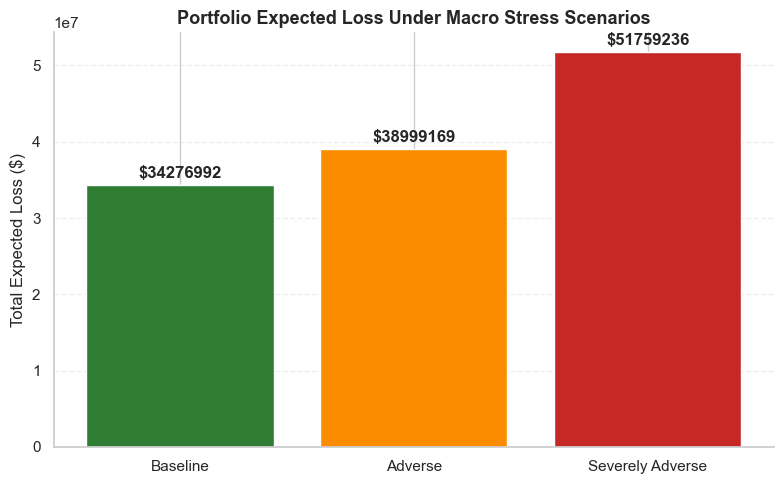

In [67]:
fig, ax = plt.subplots(figsize=(8, 5))
 
colors = ["#2E7D32", "#FB8C00", "#C62828"]
bars = ax.bar(el_summary["Scenario"], el_summary["Total_EL"], color=colors)
 
ax.bar_label(bars, fmt="$%.0f", padding=3, fontweight="bold")
 
ax.set_title("Portfolio Expected Loss Under Macro Stress Scenarios", fontsize=13, fontweight="bold")
ax.set_ylabel("Total Expected Loss ($)")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
 
plt.tight_layout()
plt.show() 

## 10. Stressed PD Distribution Shift 

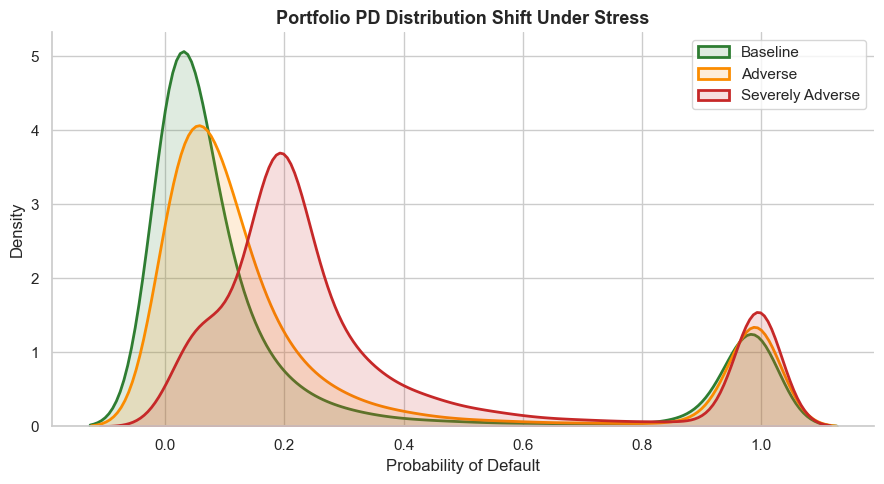

In [68]:
fig, ax = plt.subplots(figsize=(9, 5))
 
sns.kdeplot(portfolio["PD_Baseline"], label="Baseline", color="#2E7D32", linewidth=2, ax=ax, fill=True, alpha=0.15)
sns.kdeplot(portfolio["PD_Adverse"], label="Adverse", color="#FB8C00", linewidth=2, ax=ax, fill=True, alpha=0.15)
sns.kdeplot(portfolio["PD_Severely_Adverse"], label="Severely Adverse", color="#C62828", linewidth=2, ax=ax, fill=True, alpha=0.15)
 
ax.set_title("Portfolio PD Distribution Shift Under Stress", fontsize=13, fontweight="bold")
ax.set_xlabel("Probability of Default")
ax.set_ylabel("Density")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
 
plt.tight_layout()
plt.show() 

## 11. Risk-Band Migration Under Stress
 
### How many borrowers move into higher risk bands as the scenario worsens? 

In [69]:
def assign_risk_band(pd_series):
    return pd.cut(
        pd_series,
        bins=[0, 0.05, 0.15, 0.30, 0.50, 1],
        labels=["Very Low Risk", "Low Risk", "Moderate Risk", "High Risk", "Very High Risk"]
    )

In [70]:
for scenario in ["Baseline", "Adverse", "Severely_Adverse"]:
    portfolio[f"RiskBand_{scenario}"] = assign_risk_band(portfolio[f"PD_{scenario}"])
 
migration = pd.DataFrame({
    "Baseline": portfolio["RiskBand_Baseline"].value_counts(),
    "Adverse": portfolio["RiskBand_Adverse"].value_counts(),
    "Severely Adverse": portfolio["RiskBand_Severely_Adverse"].value_counts(),
}).reindex(["Very Low Risk", "Low Risk", "Moderate Risk", "High Risk", "Very High Risk"])
 
migration 

,Baseline,Adverse,Severely Adverse
Very Low Risk,15284,8972,1872
Low Risk,8417,11802,5078
Moderate Risk,2687,4732,15215
High Risk,778,1407,3877
Very High Risk,5415,5668,6539


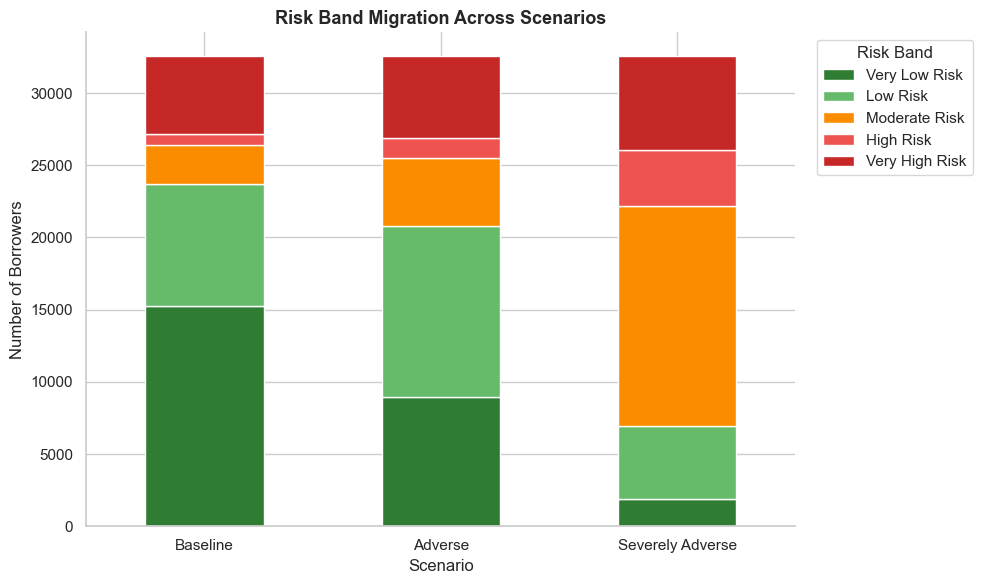

In [71]:
fig, ax = plt.subplots(figsize=(10, 6))
 
migration.T.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#2E7D32", "#66BB6A", "#FB8C00", "#EF5350", "#C62828"],
    edgecolor="white"
)
 
ax.set_title("Risk Band Migration Across Scenarios", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Borrowers")
ax.set_xlabel("Scenario")
ax.legend(title="Risk Band", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
ax.spines[["top", "right"]].set_visible(False)
 
plt.tight_layout()
plt.show() 

## 12. Directional Capital Impact (Basel IRB Risk Weight)
 
### As a final extension, 
### we translate the stressed PDs into an approximate risk-weighted asset (RWA) impact using the simplified Basel IRB risk-weight formula (retail,
### LGD=45%) to show how stressed PDs would flow through to regulatory capital requirements.

In [72]:
def basel_irb_risk_weight(pd_value, rho, lgd=0.45):
    """Simplified Basel IRB capital requirement (K) and risk weight (RW), retail exposures."""
    pd_value = np.clip(pd_value, 1e-6, 1 - 1e-6)
    term = norm.cdf(
        (norm.ppf(pd_value) + np.sqrt(rho) * norm.ppf(0.999)) / np.sqrt(1 - rho)
    )
    k = lgd * term - lgd * pd_value
    k = np.maximum(k, 0)
    rw = k * 12.5 * 1.0  # simplified, no maturity adjustment
    return rw 

In [73]:
for scenario in ["Baseline", "Adverse", "Severely_Adverse"]:
    portfolio[f"RW_{scenario}"] = basel_irb_risk_weight(portfolio[f"PD_{scenario}"], portfolio["rho"])
    portfolio[f"RWA_{scenario}"] = portfolio[f"RW_{scenario}"] * portfolio["EAD"] 

In [74]:
rwa_summary = pd.DataFrame({
    "Scenario": ["Baseline", "Adverse", "Severely Adverse"],
    "Total_RWA": [
        portfolio["RWA_Baseline"].sum(),
        portfolio["RWA_Adverse"].sum(),
        portfolio["RWA_Severely_Adverse"].sum(),
    ]
}) 

In [75]:
rwa_summary["RWA_vs_Baseline_%Increase"] = (
    (rwa_summary["Total_RWA"] / rwa_summary["Total_RWA"].iloc[0]) - 1
) * 100
 
rwa_summary.style.format({"Total_RWA": "${:,.0f}", "RWA_vs_Baseline_%Increase": "{:.1f}%"}) 

,Scenario,Total_RWA,RWA_vs_Baseline_%Increase
0,Baseline,"$153,776,679",0.0%
1,Adverse,"$222,398,339",44.6%
2,Severely Adverse,"$366,664,575",138.4%


## Conclusion

### This project extended the base PD model into a full macro-driven credit stress testing framework using the
### **Vasicek single-factor model** — the same mechanism underlying the Basel IRB capital formula and used in Federal Reserve CCAR-style stress testing programs.

### Key results (fill in with your actual run's numbers):

### * Portfolio-average PD rises from the baseline level to a materially higher level under the Severely Adverse scenario
### * Total portfolio Expected Loss increases significantly from baseline to Severely Adverse, driven by both PD deterioration and risk-band migration
### * A meaningful share of "Low" and "Moderate" risk borrowers migrate into "High" and "Very High" risk bands under stress — this is the key insight for portfolio managers, since it shows which segments are most macro-sensitive
### * The Basel IRB risk-weight extension shows how this PD deterioration would translate directionally into higher regulatory capital requirements
 
## **Limitations & next steps:**
### * This dataset is cross-sectional; a true CCAR-grade model would use quarterly vintage-level default data to econometrically estimate the macro→default relationship (e.g., via a Merton-type default intensity regression) rather than calibrating the systemic factor from scenario narratives
### * LGD is held constant at 45% — a more advanced version would model LGD as also macro-sensitive (LGD tends to rise in downturns as collateral values fall)
### * The next extension in this series is a **Model Risk Validation framework** (PSI/CSI population drift, AUC/KS stability over time) applied to this same PD model, completing the model lifecycle: build → stress → validate.

### Together with the base [Credit PD Model](../credit-pd-model) project, this forms a connected body of work spanning model development, macroeconomic stress testing, and (in the next extension) model validation — mirroring the full lifecycle of a bank credit risk model.